In [1]:
import pandas as pd
from pandas import DataFrame
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt 
import pandas as pd
from kmodes.kprototypes import KPrototypes
import seaborn as snb

In [2]:
%pip install kmodes

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
df = pd.read_csv('dados_limpos.csv')

In [4]:
scal_altura = StandardScaler()
df['altura'] = scal_altura.fit_transform(df[['altura']])

scal_idade = StandardScaler()
df['idade'] = scal_altura.fit_transform(df[['idade']])

In [5]:
df.head()

,idade,universidade,curso,periodo,ling_prog,area_atuacao,art_banda,filme_serie,comida_fav,hobby,atv_fisica,altura
0,0.533309,unifil,ciencia da computacao,7,javascript,dev,pop,fantasia,lanche,jogos,True,0.067209
1,0.894875,puc,ads,5,javascript,ciencia_dados/ia,rap,fantasia,japonesa,artes,False,-0.750990
2,-0.551387,unifil,engenharia de software,2,php,gestao/diretoria,pop,fantasia,massa,artes,False,-0.984761
3,3.064268,unifil,ciencia da computacao,4,java,ciencia_dados/ia,rock,ficção científica,massa,esporte,True,-0.049676
4,-0.189822,universidade positivo,engenharia de software,7,python,ciencia_dados/ia,rock,drama,massa,jogos,False,0.651637


In [6]:
model = KPrototypes(
    n_clusters=3,
    random_state=42
)

cat_cols = ['universidade', 'curso', 'ling_prog','area_atuacao', 'atv_fisica',
            'art_banda', 'filme_serie', 'comida_fav', 'hobby']

categorical_indices = [
    df.columns.get_loc(column)
    for column in cat_cols
]


clusters = model.fit_predict(
    df,
    categorical=categorical_indices
)

In [7]:
print(clusters)

[2 0 1 0 2 2 1 1 2 2 0 1 2 1 2 1 1 1 0 2 1 1 2 1 2 0 2 2 1 1 1 2 2 2 2 2 1
 0 2 0]


In [8]:
df["cluster"] = clusters

In [9]:
df.to_csv("dados_clusterizados.csv", index=False)

In [10]:
def plot_histograma(df: DataFrame , col: str):
    graphs = snb.displot(data=df, x=col, hue='cluster', col='cluster', aspect=0.6)

    for ax in graphs.axes.flat:
        ax.tick_params(axis='x', labelrotation=90)
    


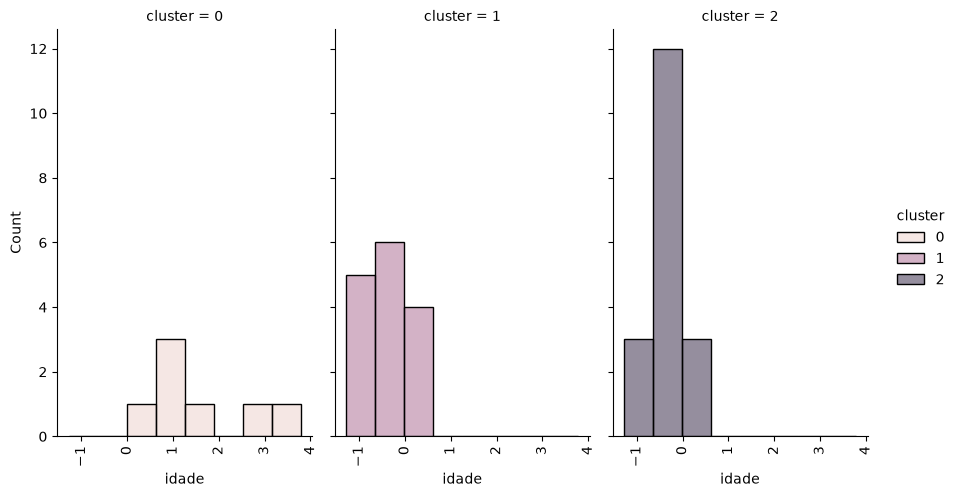

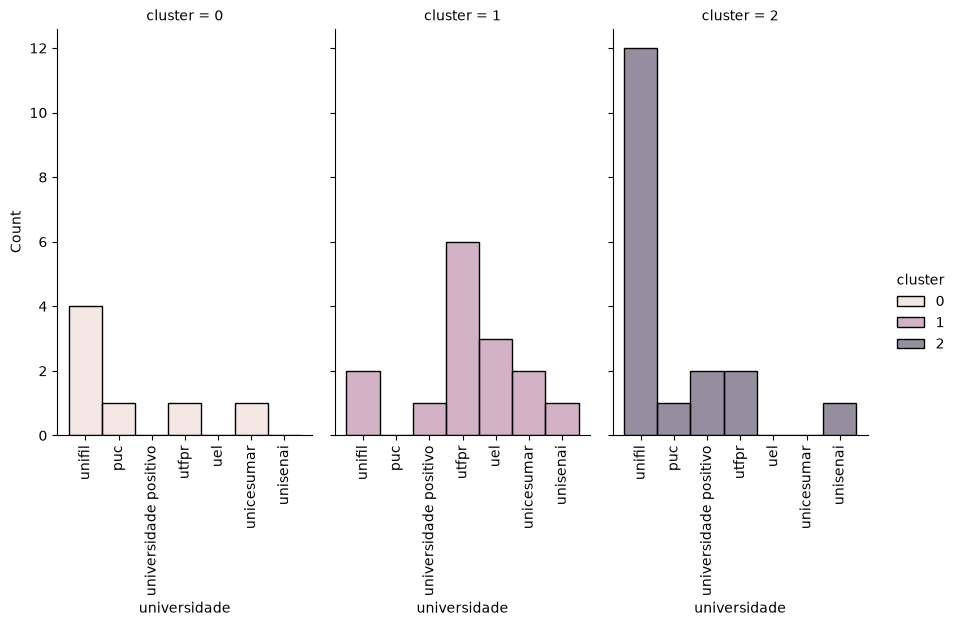

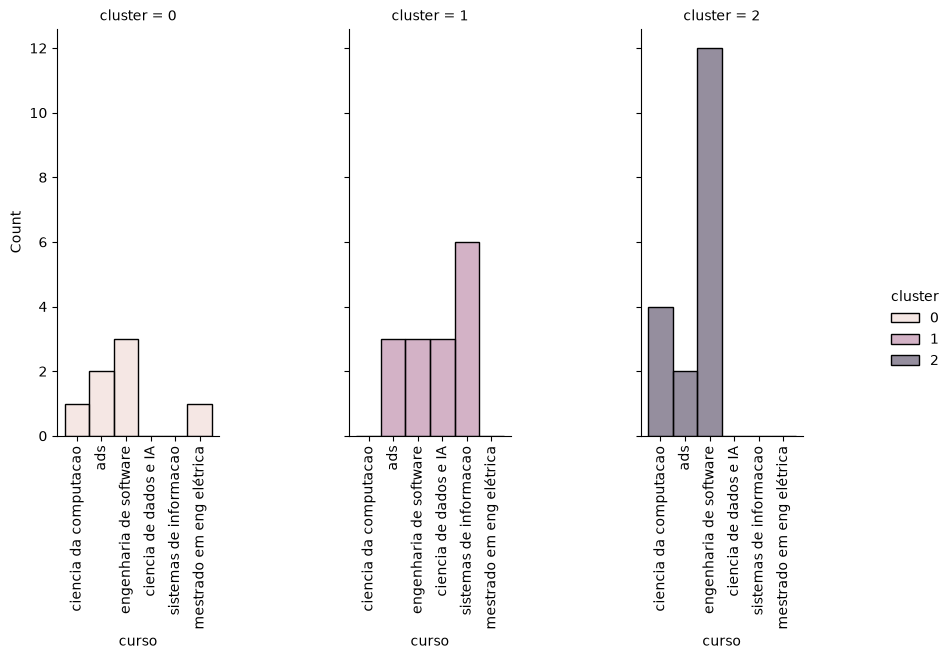

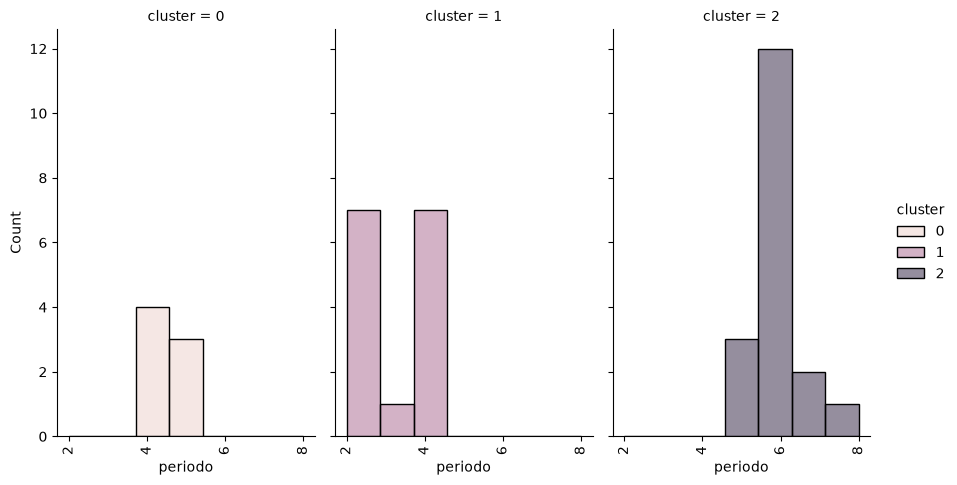

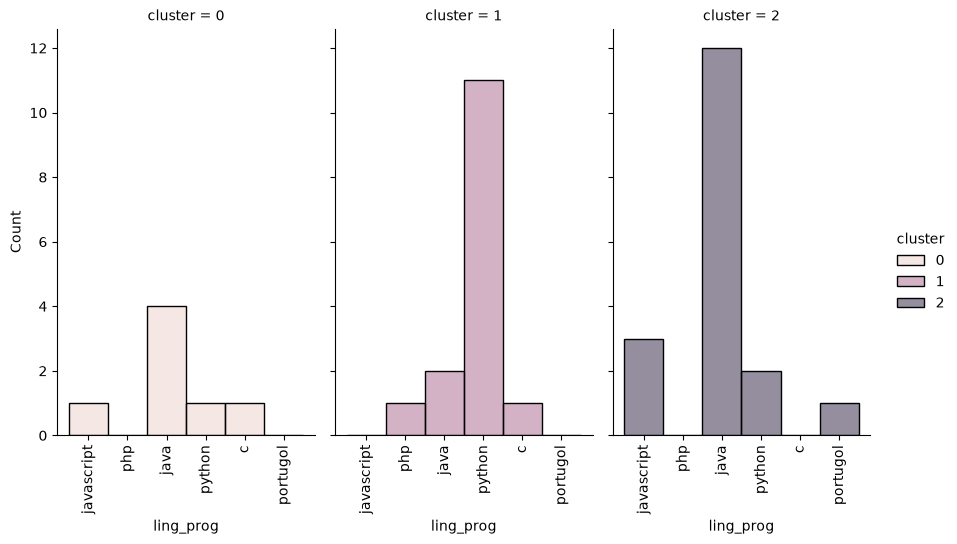

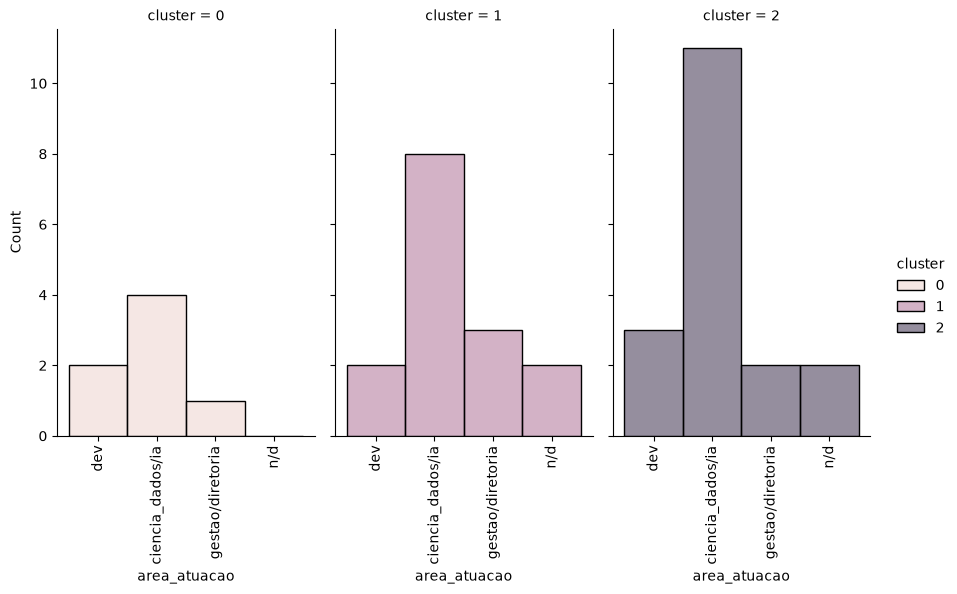

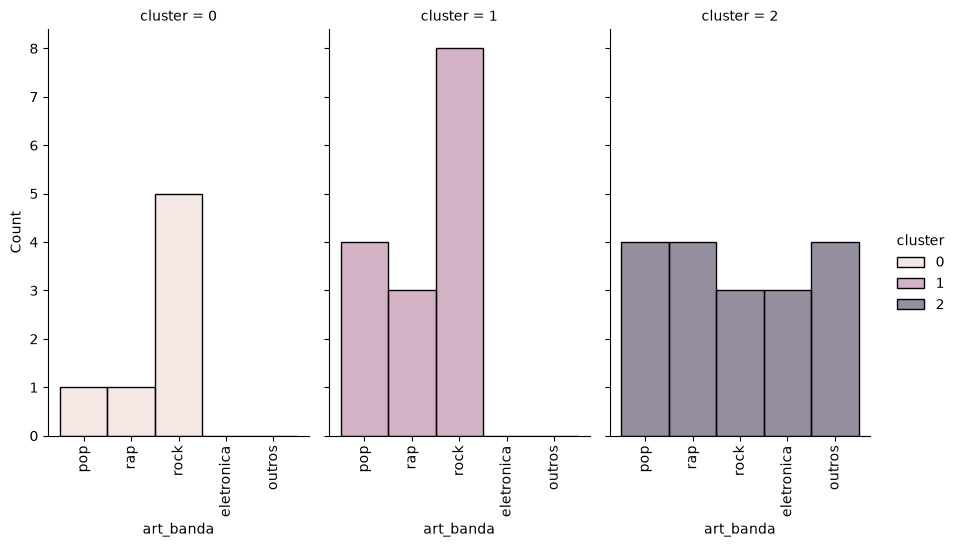

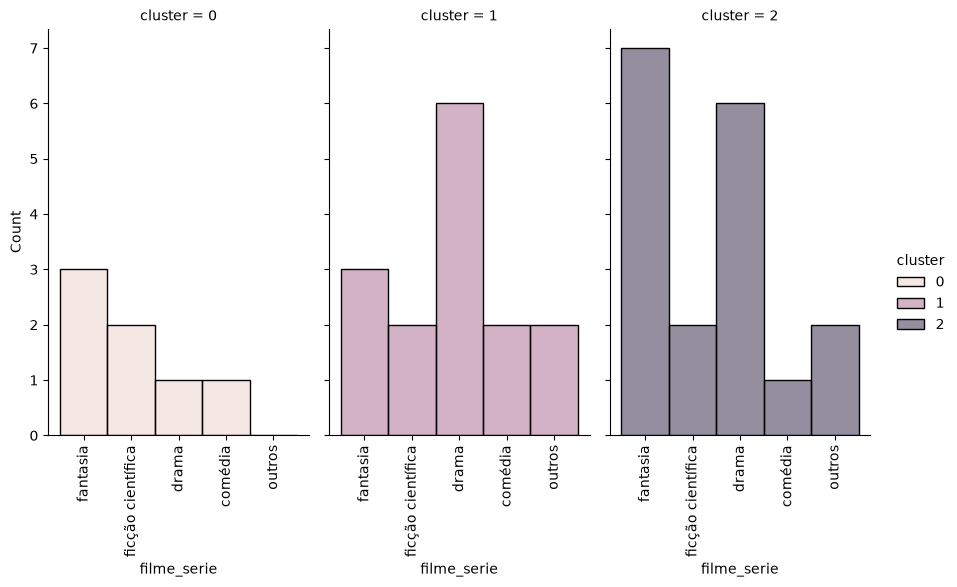

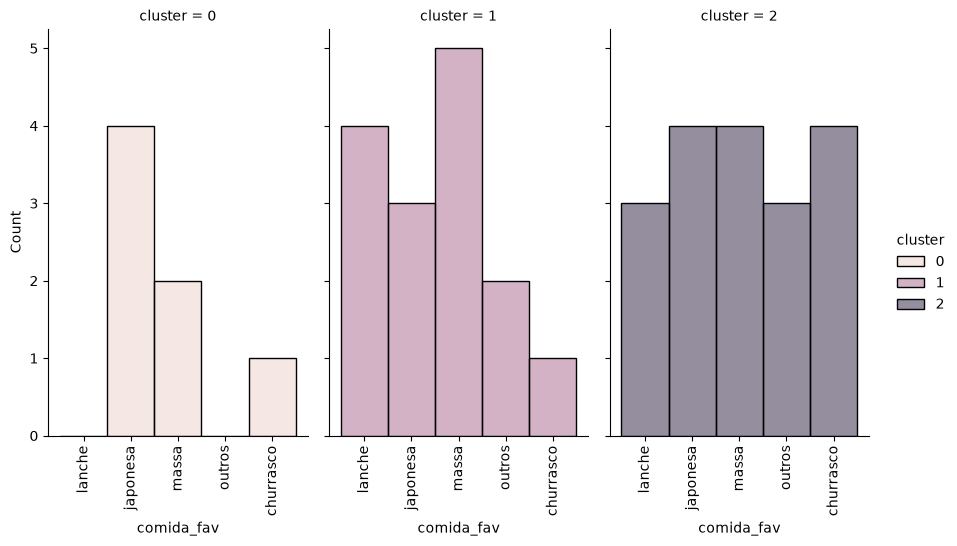

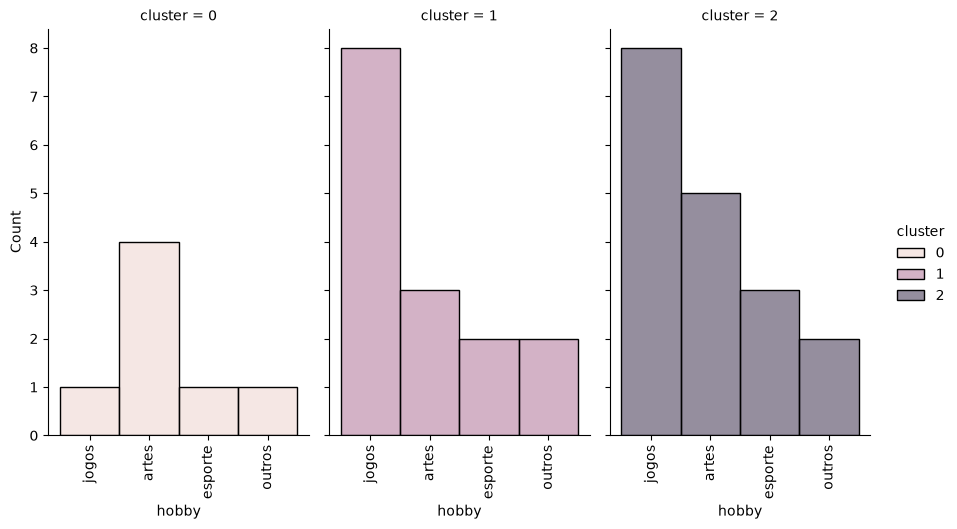

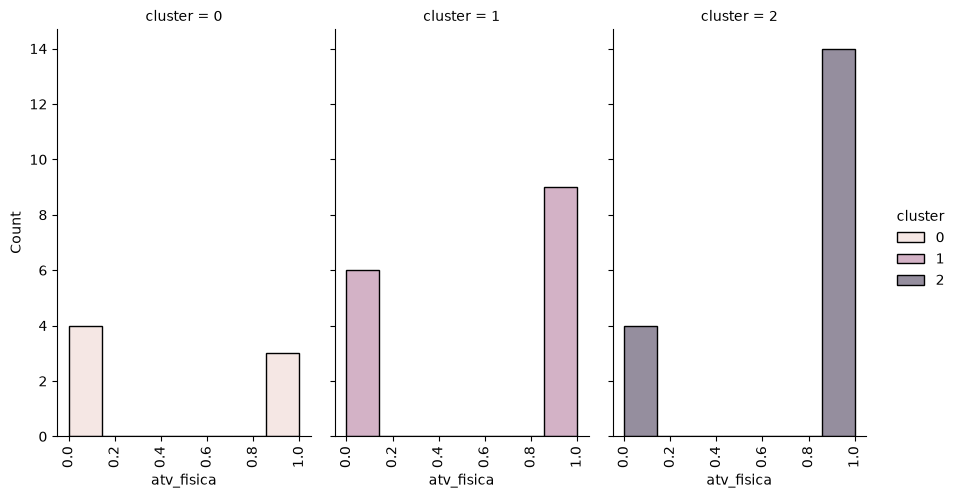

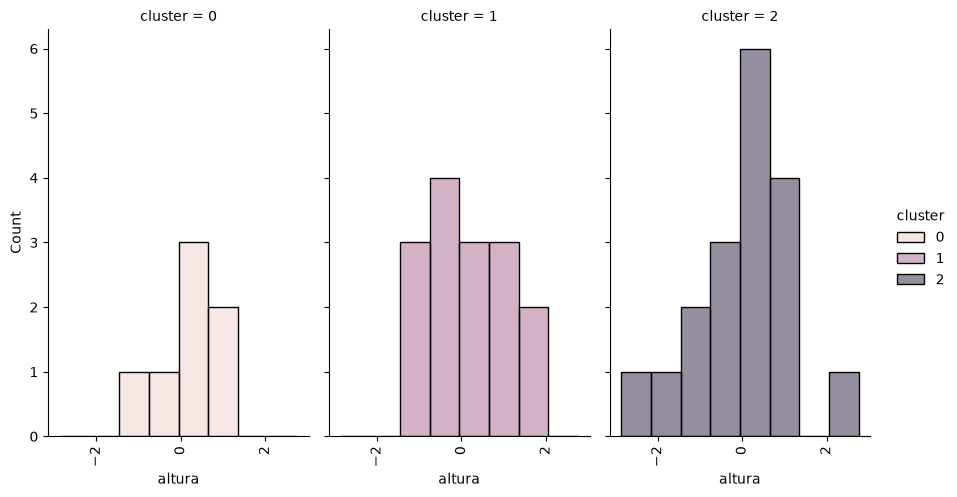

In [11]:
for col in df.columns:
    if col != 'cluster': 
        plot_histograma(df, col)